In [2]:
import sys
sys.path.append("/global/homes/z/zzhang13/DESI")
from setup import *

from tools.notebook_setup import *
from tools.projection_functions import *


bgs_matched, zbin, lmda_bins, z_bins = prepare_default_richness_inputs()

binBoundaries = zbin.bin_boundaries
binCent = zbin.bin_centers
bin_width = zbin.bin_widths
micro_bin = zbin.micro_bin_boundaries
binCent_micro = zbin.micro_bin_centers

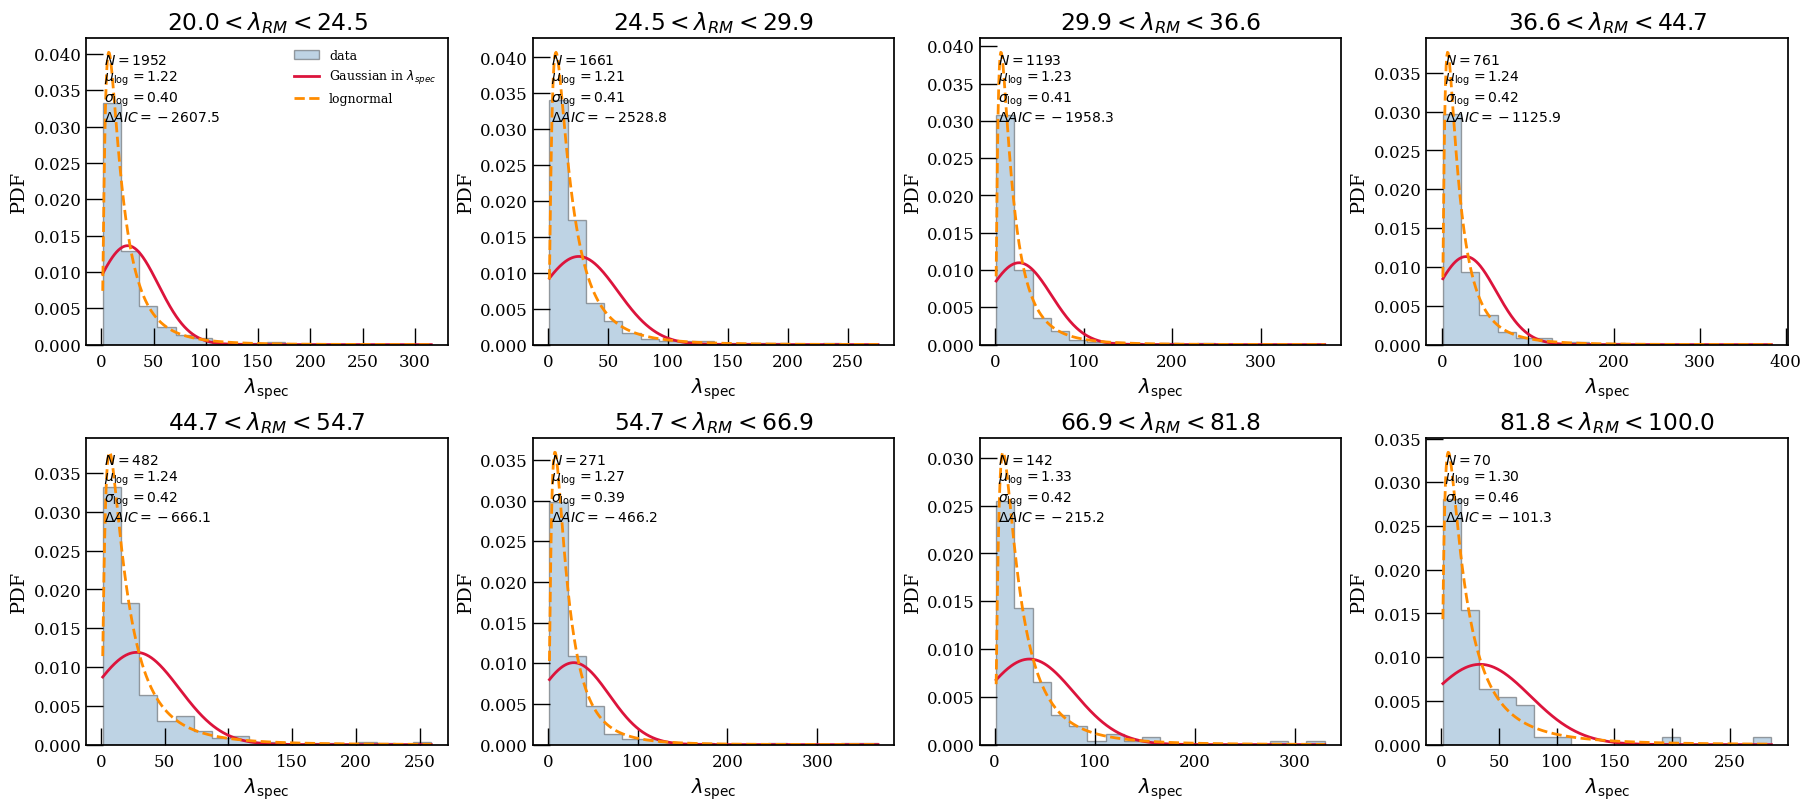

,lambda_rm_low,lambda_rm_high,N,mean_lambda_spec,std_lambda_spec,mean_log10_lambda_spec,std_log10_lambda_spec,skew_log10,kurtosis_log10,AIC_gaussian_linear,AIC_lognormal,delta_AIC_lognormal_minus_gaussian
0,20.000000,24.456891,1952,25.212585,29.305110,1.216843,0.396116,0.066368,0.106694,18729.318552,16121.856841,-2607.461711
1,24.456891,29.906976,1661,25.784172,32.493859,1.210247,0.406200,0.181493,0.138215,16280.765646,13751.950213,-2528.815433
2,29.906976,36.571582,1193,27.202326,36.361086,1.225616,0.413392,0.173027,0.161379,11962.676270,10004.390194,-1958.286077
3,36.571582,44.721360,761,28.126423,35.201845,1.242680,0.417260,0.107422,0.037562,7582.616358,6456.739153,-1125.877205
4,44.721360,54.687271,482,28.028157,33.580377,1.242626,0.417979,0.093597,0.020635,4758.296714,4092.192368,-666.104345
5,54.687271,66.874030,271,28.898933,39.589172,1.265877,0.394383,0.197797,0.488682,2765.841844,2299.632500,-466.209345
6,66.874030,81.776543,142,34.768938,44.556438,1.332522,0.421824,0.023651,0.367774,1484.257434,1269.086016,-215.171418
7,81.776543,100.000000,70,33.764599,43.451907,1.295644,0.463469,-0.143396,-0.005064,729.683057,628.419754,-101.263302


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm, skew, kurtosis
from astropy.table import unique

table = bgs_matched

redmapper_col = "LAMBDA"
id_col = "ID"

rm_bins = np.logspace(np.log10(20), np.log10(100), 9)  # 8 bins

# ------------------------------------------------------------
# Compute individual spectroscopic richnesses once
# ------------------------------------------------------------

id_ind, _, lambda_spec_ind = calc_specRichness_individual(
    binBoundaries,
    binCent,
    table,
)

id_ind = np.asarray(id_ind)
lambda_spec_ind = np.asarray(lambda_spec_ind, dtype=float)

# Map cluster ID -> redMaPPer richness
table_unique = unique(table, keys=id_col)
id_to_rm = {
    row[id_col]: float(row[redmapper_col])
    for row in table_unique
}

rows = []
for cid, lam_spec in zip(id_ind, lambda_spec_ind):
    if cid in id_to_rm and np.isfinite(lam_spec) and lam_spec > 0:
        rows.append(
            {
                "ID": cid,
                "lambda_rm": id_to_rm[cid],
                "lambda_spec": lam_spec,
                "log_lambda_spec": np.log10(lam_spec),
            }
        )

rich_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Plot lambda_spec distributions in redMaPPer richness bins
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 8),
    sharey=False,
    constrained_layout=True,
)

axes = axes.reshape(-1)

summary_rows = []

for i, (lo, hi) in enumerate(zip(rm_bins[:-1], rm_bins[1:])):
    ax = axes[i]

    sub = rich_df[
        (rich_df["lambda_rm"] >= lo)
        & (rich_df["lambda_rm"] < hi)
    ]

    lam = np.asarray(sub["lambda_spec"], dtype=float)
    lam = lam[np.isfinite(lam) & (lam > 0)]

    if len(lam) < 3:
        ax.text(
            0.5,
            0.5,
            f"N={len(lam)}",
            transform=ax.transAxes,
            ha="center",
            va="center",
        )
        ax.set_title(rf"${lo:.1f}<\lambda_{{RM}}<{hi:.1f}$")
        continue

    log_lam = np.log10(lam)

    # Histogram in linear lambda_spec
    counts, edges, _ = ax.hist(
        lam,
        bins=18,
        density=True,
        histtype="stepfilled",
        alpha=0.35,
        color="steelblue",
        edgecolor="black",
        label="data",
    )

    xgrid = np.linspace(np.nanmin(lam), np.nanmax(lam), 500)

    # --------------------------------------------------------
    # Model 1: Gaussian in linear lambda_spec
    # --------------------------------------------------------
    mu_lin = np.nanmean(lam)
    sig_lin = np.nanstd(lam, ddof=1)

    if sig_lin > 0:
        pdf_norm = norm.pdf(xgrid, loc=mu_lin, scale=sig_lin)
        ax.plot(
            xgrid,
            pdf_norm,
            color="crimson",
            lw=2,
            label="Gaussian in $\\lambda_{spec}$",
        )

        loglike_norm = np.sum(norm.logpdf(lam, loc=mu_lin, scale=sig_lin))
        aic_norm = 2 * 2 - 2 * loglike_norm
    else:
        aic_norm = np.nan

    # --------------------------------------------------------
    # Model 2: Lognormal, equivalent to Gaussian in log(lambda_spec)
    # scipy lognorm uses natural-log sigma.
    # --------------------------------------------------------
    mu_log10 = np.nanmean(log_lam)
    sig_log10 = np.nanstd(log_lam, ddof=1)

    if sig_log10 > 0:
        sigma_ln = sig_log10 * np.log(10)
        scale_ln = np.exp(mu_log10 * np.log(10))

        pdf_lognorm = lognorm.pdf(
            xgrid,
            s=sigma_ln,
            loc=0,
            scale=scale_ln,
        )

        ax.plot(
            xgrid,
            pdf_lognorm,
            color="darkorange",
            lw=2,
            ls="--",
            label="lognormal",
        )

        loglike_lognorm = np.sum(
            lognorm.logpdf(
                lam,
                s=sigma_ln,
                loc=0,
                scale=scale_ln,
            )
        )
        aic_lognorm = 2 * 2 - 2 * loglike_lognorm
    else:
        aic_lognorm = np.nan

    delta_aic = aic_lognorm - aic_norm

    summary_rows.append(
        {
            "lambda_rm_low": lo,
            "lambda_rm_high": hi,
            "N": len(lam),
            "mean_lambda_spec": np.nanmean(lam),
            "std_lambda_spec": np.nanstd(lam, ddof=1),
            "mean_log10_lambda_spec": mu_log10,
            "std_log10_lambda_spec": sig_log10,
            "skew_log10": skew(log_lam, nan_policy="omit"),
            "kurtosis_log10": kurtosis(log_lam, nan_policy="omit"),
            "AIC_gaussian_linear": aic_norm,
            "AIC_lognormal": aic_lognorm,
            "delta_AIC_lognormal_minus_gaussian": delta_aic,
        }
    )

    ax.set_title(rf"${lo:.1f}<\lambda_{{RM}}<{hi:.1f}$")
    ax.set_xlabel(r"$\lambda_{\rm spec}$")
    ax.set_ylabel("PDF")

    ax.text(
        0.05,
        0.95,
        "\n".join(
            [
                rf"$N={len(lam)}$",
                rf"$\mu_{{\log}}={mu_log10:.2f}$",
                rf"$\sigma_{{\log}}={sig_log10:.2f}$",
                rf"$\Delta AIC={delta_aic:.1f}$",
            ]
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
    )

    if i == 0:
        ax.legend(frameon=False, fontsize=9)

summary_df = pd.DataFrame(summary_rows)

plt.show()

summary_df


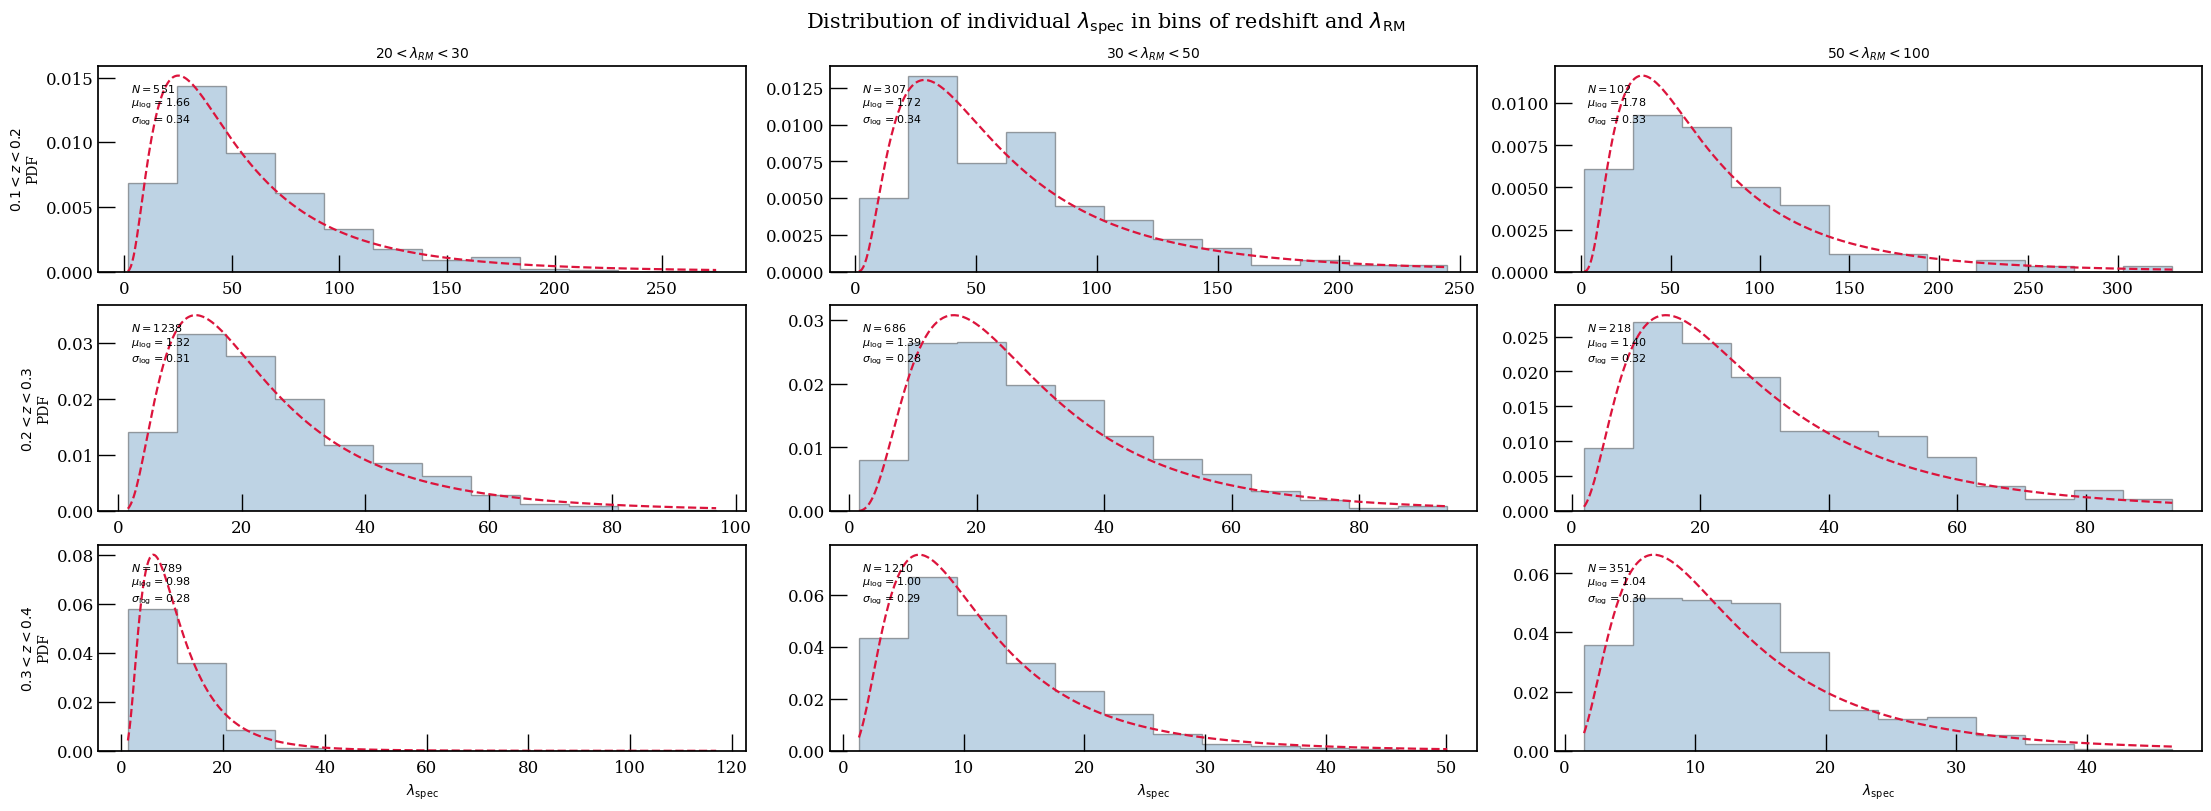

,z_low,z_high,lambda_rm_low,lambda_rm_high,N,mean_lambda_spec,std_lambda_spec,mean_log10_lambda_spec,std_log10_lambda_spec,skew_log10,kurtosis_log10,AIC_lognormal
0,0.1,0.2,20,30,551,58.900307,40.862279,1.661254,0.337368,-0.948888,2.115919,5503.707850
1,0.1,0.2,30,50,307,68.328259,46.545228,1.724509,0.340484,-0.915191,1.783680,3162.897505
2,0.1,0.2,50,100,102,76.817469,55.128208,1.780904,0.327435,-1.015460,3.830811,1071.386174
3,0.2,0.3,20,30,1238,25.612970,15.809671,1.316375,0.308020,-0.851479,1.287913,10170.561564
4,0.2,0.3,30,50,686,29.749898,17.136374,1.394932,0.279438,-0.733561,1.312503,5751.603955
5,0.2,0.3,50,100,218,31.752197,20.090440,1.402838,0.320908,-0.831387,1.166509,1898.083974
6,0.3,0.4,20,30,1789,11.494550,7.143105,0.979746,0.278099,-0.486376,0.188534,11556.870184
7,0.3,0.4,30,50,1210,12.123386,7.599081,0.995726,0.290816,-0.451079,0.009151,8014.772619
8,0.3,0.4,50,100,351,13.554587,8.182272,1.042872,0.301113,-0.699002,0.334951,2427.711245


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm, skew, kurtosis
from astropy.table import unique

table = bgs_matched

redmapper_col = "LAMBDA"
id_col = "ID"
z_col = "Z_SPEC_x"

z_bins = [[0.1, 0.2], [0.2, 0.3], [0.3, 0.4]]
rm_bins = [20,30,50,100]  

# ------------------------------------------------------------
# Compute individual spectroscopic richnesses once
# ------------------------------------------------------------

id_ind, _, lambda_spec_ind = calc_specRichness_individual(
    binBoundaries,
    binCent,
    table,
)

id_ind = np.asarray(id_ind)
lambda_spec_ind = np.asarray(lambda_spec_ind, dtype=float)

table_unique = unique(table, keys=id_col)

id_to_rm = {
    row[id_col]: float(row[redmapper_col])
    for row in table_unique
}

id_to_z = {
    row[id_col]: float(row[z_col])
    for row in table_unique
}

rows = []

for cid, lam_spec in zip(id_ind, lambda_spec_ind):
    if (
        cid in id_to_rm
        and cid in id_to_z
        and np.isfinite(lam_spec)
        and lam_spec > 0
    ):
        rows.append(
            {
                "ID": cid,
                "lambda_rm": id_to_rm[cid],
                "z": id_to_z[cid],
                "lambda_spec": lam_spec,
                "log_lambda_spec": np.log10(lam_spec),
            }
        )

rich_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Plot distributions: rows = redshift bins, columns = RM bins
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(z_bins),
    len(rm_bins) - 1,
    figsize=(22, 8),
    sharex=False,
    sharey=False,
    constrained_layout=True,
)

summary_rows = []

for iz, (zlo, zhi) in enumerate(z_bins):
    for ir, (rlo, rhi) in enumerate(zip(rm_bins[:-1], rm_bins[1:])):
        ax = axes[iz, ir]

        sub = rich_df[
            (rich_df["z"] >= zlo)
            & (rich_df["z"] < zhi)
            & (rich_df["lambda_rm"] >= rlo)
            & (rich_df["lambda_rm"] < rhi)
        ]

        lam = np.asarray(sub["lambda_spec"], dtype=float)
        lam = lam[np.isfinite(lam) & (lam > 0)]

        if len(lam) < 3:
            ax.text(
                0.5,
                0.5,
                rf"$N={len(lam)}$",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=9,
            )
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            log_lam = np.log10(lam)

            ax.hist(
                lam,
                bins=12,
                density=True,
                histtype="stepfilled",
                alpha=0.35,
                color="steelblue",
                edgecolor="black",
            )

            mu_log10 = np.nanmean(log_lam)
            sig_log10 = np.nanstd(log_lam, ddof=1)

            if sig_log10 > 0:
                xgrid = np.linspace(np.nanmin(lam), np.nanmax(lam), 400)

                sigma_ln = sig_log10 * np.log(10)
                scale_ln = np.exp(mu_log10 * np.log(10))

                pdf_lognorm = lognorm.pdf(
                    xgrid,
                    s=sigma_ln,
                    loc=0,
                    scale=scale_ln,
                )

                ax.plot(
                    xgrid,
                    pdf_lognorm,
                    color="crimson",
                    lw=1.6,
                    ls="--",
                )

                loglike_lognorm = np.sum(
                    lognorm.logpdf(
                        lam,
                        s=sigma_ln,
                        loc=0,
                        scale=scale_ln,
                    )
                )

                aic_lognorm = 2 * 2 - 2 * loglike_lognorm
            else:
                aic_lognorm = np.nan

            summary_rows.append(
                {
                    "z_low": zlo,
                    "z_high": zhi,
                    "lambda_rm_low": rlo,
                    "lambda_rm_high": rhi,
                    "N": len(lam),
                    "mean_lambda_spec": np.nanmean(lam),
                    "std_lambda_spec": np.nanstd(lam, ddof=1),
                    "mean_log10_lambda_spec": mu_log10,
                    "std_log10_lambda_spec": sig_log10,
                    "skew_log10": skew(log_lam, nan_policy="omit"),
                    "kurtosis_log10": kurtosis(log_lam, nan_policy="omit"),
                    "AIC_lognormal": aic_lognorm,
                }
            )

            ax.text(
                0.05,
                0.92,
                "\n".join(
                    [
                        rf"$N={len(lam)}$",
                        rf"$\mu_{{\log}}={mu_log10:.2f}$",
                        rf"$\sigma_{{\log}}={sig_log10:.2f}$",
                    ]
                ),
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8,
            )

        if iz == 0:
            ax.set_title(
                rf"${rlo:.0f}<\lambda_{{RM}}<{rhi:.0f}$",
                fontsize=10,
            )

        if ir == 0:
            ax.set_ylabel(
                rf"${zlo}<z<{zhi}$" + "\nPDF",
                fontsize=10,
            )

        if iz == len(z_bins) - 1:
            ax.set_xlabel(r"$\lambda_{\rm spec}$", fontsize=10)

summary_df = pd.DataFrame(summary_rows)

fig.suptitle(
    r"Distribution of individual $\lambda_{\rm spec}$ in bins of redshift and $\lambda_{\rm RM}$",
    fontsize=15,
)

plt.savefig(plots_dir() + 'richness_conditional_pdf.jpeg')
plt.show()

summary_df
